# Proyek Analisis Data: E-Commerce
- **Nama:** Zifa Berliandri
- **Email:** cdcc180d6x1034@student.devacademy.id
- **ID Dicoding:** CDCC180D6X1034

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Apakah terdapat perbedaan signifikan pada rata-rata review score antara pesanan yang dikirim tepat waktu dan pesanan yang terlambat selama September 2016 hingga Agustus 2018?
- **Pertanyaan 2:** Metode pembayaran apa yang paling banyak digunakan dan menghasilkan total transaksi terbesar selama periode September 2016 hingga Agustus 2018?
- **Pertanyaan 3:** Bagaimana distribusi pelanggan ke dalam segmen berdasarkan analisis RFM selama periode September 2016 hingga Agustus 2018?

## Import Semua Packages/Library yang Digunakan

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]=(10, 6)
pd.set_option("display.max_columns", None)

## Data Wrangling

In [56]:
from pathlib import Path

BASE_DIR = Path('/content/')

### Gathering Data

In [57]:
orders_df = pd.read_csv('/content/orders_dataset.csv')
reviews_df = pd.read_csv('/content/order_reviews_dataset.csv')
payments_df = pd.read_csv('/content/order_payments_dataset.csv')

display(orders_df.head())
display(reviews_df.head())
display(payments_df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**
- Pada dataset orders_df, sebagian besar pesanan memiliki status delivered, yang menunjukkan bahwa mayoritas transaksi berhasil diselesaikan.
- Dataset terdiri dari beberapa tabel utama yaitu orders, reviews, dan payments yang saling terhubung melalui kolom order_id, sehingga memungkinkan analisis yang lebih komprehensif terkait transaksi pelanggan.
- Pada dataset reviews_df, terdapat banyak missing values pada kolom review_comment_title dan review_comment_message, yang mengindikasikan bahwa tidak semua pelanggan memberikan ulasan berupa teks.
- Dataset payments_df menunjukkan bahwa metode pembayaran yang sering digunakan adalah credit card, dengan variasi jumlah cicilan (installments) yang berbeda-beda.
- Nilai pembayaran (payment_value) bervariasi antar transaksi, yang mencerminkan adanya perbedaan harga produk atau jumlah item dalam setiap pesanan.
- * Secara keseluruhan, data sudah cukup lengkap untuk analisis lebih lanjut, namun perlu diperhatikan penanganan missing values pada dataset reviews sebelum masuk ke tahap analisis berikutnya.

### Assessing Data

In [58]:
## === ORDERS ===
orders_df.info()
orders_df.isna().sum()
orders_df.duplicated().sum()

## === REVIEWS ===
reviews_df.info()
reviews_df.isna().sum()
reviews_df.duplicated().sum()

## === PAYMENTS ===
payments_df.info()
payments_df.isna().sum()
payments_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  ob

np.int64(0)

#### **insight**

- terdapat missing value pada beberapa kolom orders_df terkait proses pengiriman seperti order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date. Hal tersebut mungkin disebabkan oleh pesanan yang belum selesai atau dibatalkan.
- Seluruh kolom tanggal pada orders_df masih bertipe object sehingga perlu dikonversi ke tipe datetime.
- terdapat missing value yang cukup besar pada dataset reviews_df seperti pada kolom review_comment_title dan review_comment_message, yang menunjukkan bahwa tidak semua pengguna memberikan komentar.
- pada dataset payments_df tidak memiliki missing value maupun data duplikat sehingga tidak memerlukan proces cleaning.
- diperlukan proces cleaning terutama pada penanganan missing value dan konversi tipe data sebelum analisis lebih lanjut.

### Cleaning Data

In [59]:
orders_df.drop_duplicates(inplace=True)
reviews_df.drop_duplicates(inplace=True)
payments_df.drop_duplicates(inplace=True)
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(
        orders_df[col],
        errors='coerce'
    )
orders_df = orders_df[
    (orders_df['order_purchase_timestamp'] >= '2016-09-01') &
    (orders_df['order_purchase_timestamp'] <= '2018-08-31')
]
orders_rfm_df = orders_df.copy()
orders_df = orders_df.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
reviews_df = reviews_df[
    reviews_df['review_score'].between(1,5)
]
orders_df['delivery_status'] = np.where(
    orders_df['order_delivered_customer_date'] <=
    orders_df['order_estimated_delivery_date'],
    'On Time',
    'Late'
)
orders_rfm_df = orders_rfm_df.dropna(subset=[
    'customer_id',
    'order_purchase_timestamp'
])

payments_df = payments_df.dropna(subset=[
    'payment_value'
])

**Insight**


- Data duplikat pada orders_df, reviews_df, dan payments_df telah dihapus untuk mencegah analisis yang bias.
- Kolom-kolom tanggal pada orders_df telah dikonversi ke tipe data datetime agar bisa digunakan untuk analisis waktu.
- Data orders_df difilter pada rentang tanggal 2016-09-01 sampai 2018-08-31 agar periode analisis lebih konsisten.
- Missing value pada kolom order_delivered_customer_date dan order_estimated_delivery_date dihapus karena kolom tersebut dibutuhkan untuk menentukan status keterlambatan pengiriman.
- Nilai review_score difilter agar hanya berada pada rentang valid 1 sampai 5.
- Kolom baru delivery_status dibuat untuk mengelompokkan pesanan menjadi On Time dan Late.
- Dataset orders_rfm_df dibersihkan dari missing value pada customer_id dan order_purchase_timestamp karena kolom tersebut penting untuk analisis RFM.
- Proses cleaning ini dilakukan agar data lebih rapi, konsisten, dan siap digunakan pada tahap EDA.

## Exploratory Data Analysis (EDA)

### Explore ...

  delivery_status  review_score
0            Late      2.566550
1         On Time      4.293578
  delivery_status  review_score
0            Late      2.566550
1         On Time      4.293578


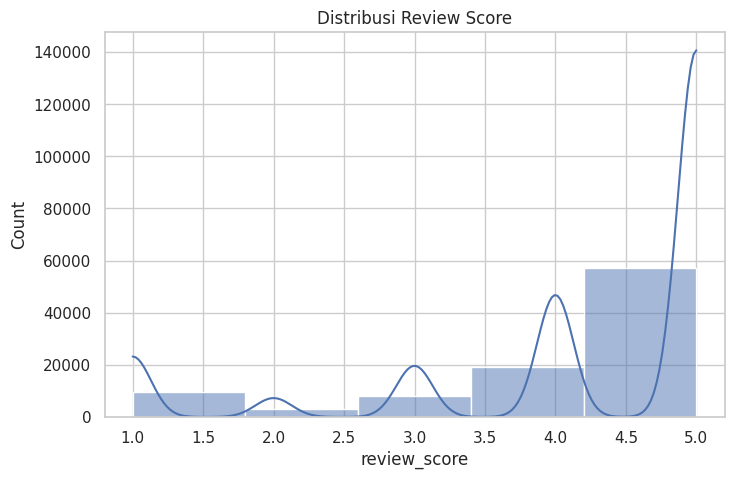

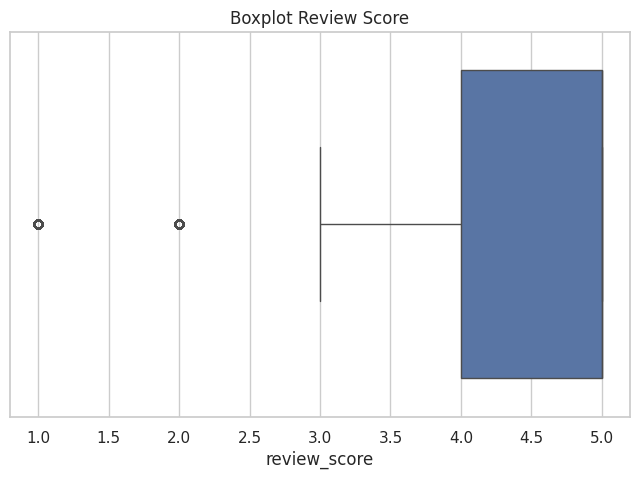

Skewness : -1.4821281169615288
Kurtosis : 0.955975018036126
Percentile Review Score
0.25    4.0
0.50    5.0
0.75    5.0
Name: review_score, dtype: float64
Shapiro Test p-value : 2.3891197258698708e-70
Data tidak normal


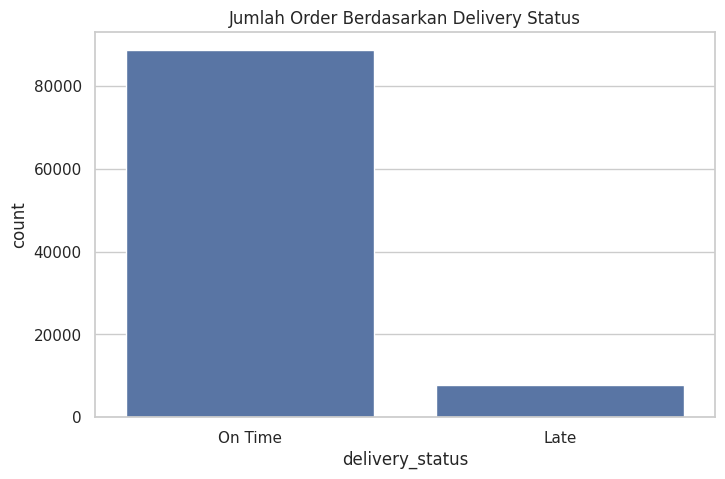

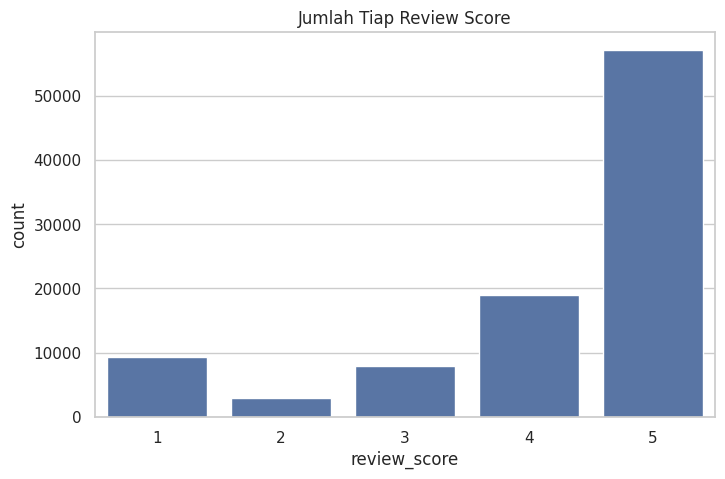

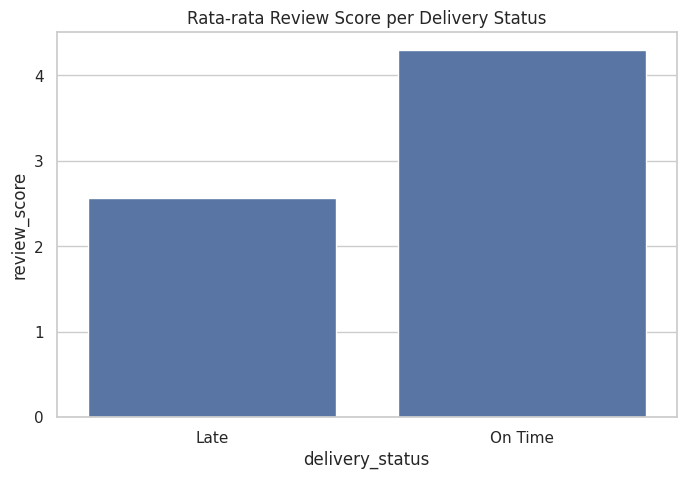

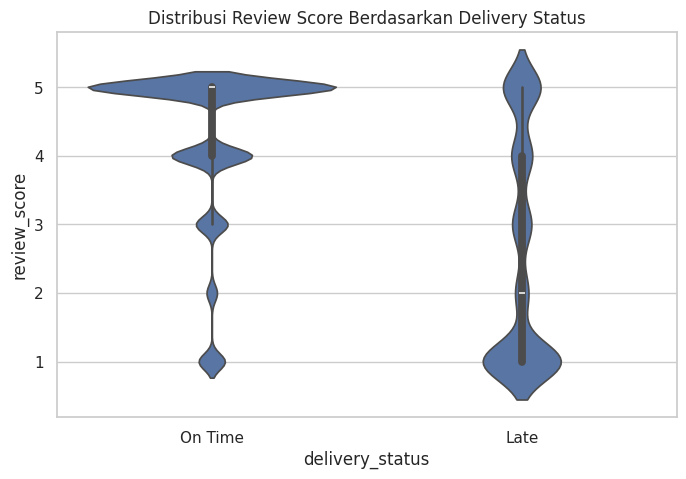

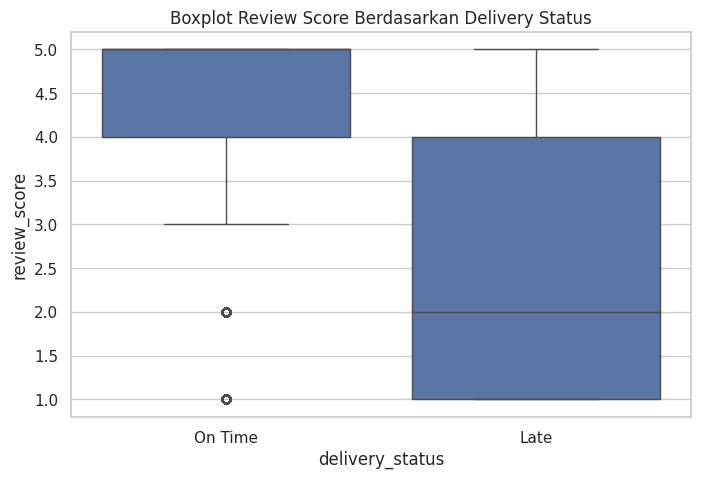

Chi-square p-value : 0.0
Ada hubungan signifikan antara delivery_status dan review_score


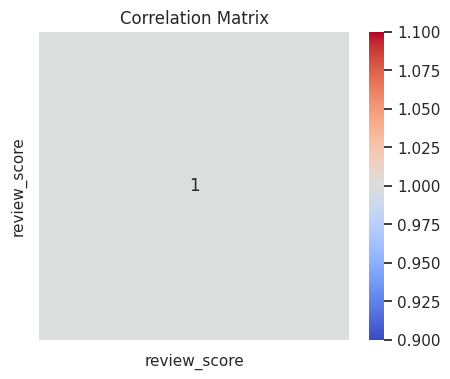

In [60]:
review_order_df = pd.merge(
    orders_df[['order_id','delivery_status']],
    reviews_df[['order_id','review_score']],
    on='order_id',
    how='inner'
)

avg_review = review_order_df.groupby('delivery_status')['review_score'].mean().reset_index()
print(avg_review)
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
sns.set(style="whitegrid")
review_order_df = pd.merge(
    orders_df[['order_id','delivery_status']],
    reviews_df[['order_id','review_score']],
    on='order_id',
    how='inner'
)
avg_review = review_order_df.groupby(
    'delivery_status'
)['review_score'].mean().reset_index()

print(avg_review)
plt.figure(figsize=(8,5))
sns.histplot(review_order_df['review_score'], kde=True, bins=5)
plt.title("Distribusi Review Score")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x=review_order_df['review_score'])
plt.title("Boxplot Review Score")
plt.show()
print("Skewness :", review_order_df['review_score'].skew())
print("Kurtosis :", review_order_df['review_score'].kurt())
print("Percentile Review Score")
print(review_order_df['review_score'].quantile([0.25,0.5,0.75]))
stat, p = stats.shapiro(review_order_df['review_score'].sample(5000, random_state=42))
print("Shapiro Test p-value :", p)

if p > 0.05:
    print("Data berdistribusi normal")
else:
    print("Data tidak normal")
plt.figure(figsize=(8,5))
sns.countplot(data=review_order_df, x='delivery_status')
plt.title("Jumlah Order Berdasarkan Delivery Status")
plt.show()
plt.figure(figsize=(8,5))
sns.countplot(data=review_order_df, x='review_score')
plt.title("Jumlah Tiap Review Score")
plt.show()
plt.figure(figsize=(8,5))
sns.barplot(data=avg_review, x='delivery_status', y='review_score')
plt.title("Rata-rata Review Score per Delivery Status")
plt.show()
plt.figure(figsize=(8,5))
sns.violinplot(data=review_order_df, x='delivery_status', y='review_score')
plt.title("Distribusi Review Score Berdasarkan Delivery Status")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(data=review_order_df, x='delivery_status', y='review_score')
plt.title("Boxplot Review Score Berdasarkan Delivery Status")
plt.show()
contingency_table = pd.crosstab(
    review_order_df['delivery_status'],
    review_order_df['review_score']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square p-value :", p)

if p < 0.05:
    print("Ada hubungan signifikan antara delivery_status dan review_score")
else:
    print("Tidak ada hubungan signifikan")
numeric_df = review_order_df[['review_score']]

plt.figure(figsize=(5,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Insight:**
- Order tepat waktu cenderung memiliki review score lebih tinggi
- Distribusi review score dominan pada nilai tinggi
- Terdapat hubungan signifikan antara keterlambatan dan review score

## Visualization & Explanatory Analysis

### Pertanyaan 1: Apakah terdapat perbedaan signifikan pada rata-rata review score antara pesanan yang dikirim tepat waktu dan pesanan yang terlambat selama September 2016 hingga Agustus 2018?

  delivery_status  review_score
0            Late      2.566550
1         On Time      4.293578


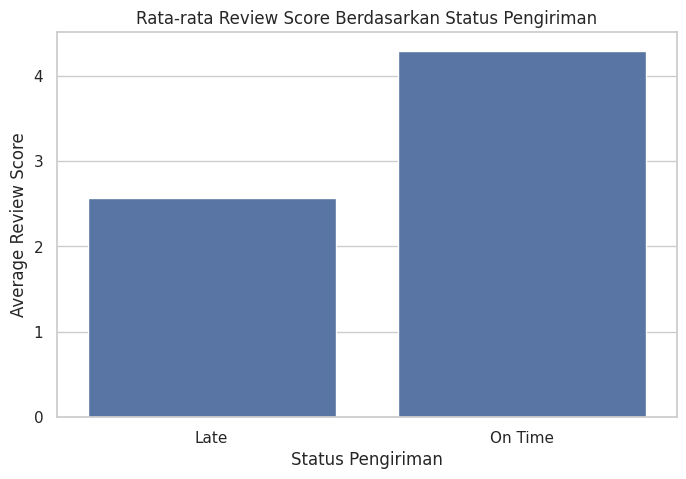

In [61]:
review_order_df = pd.merge(
    orders_df[['order_id','delivery_status']],
    reviews_df[['order_id','review_score']],
    on='order_id',
    how='inner'
)

avg_review = review_order_df.groupby('delivery_status')['review_score'].mean().reset_index()
print(avg_review)
plt.figure(figsize=(8,5))
sns.barplot(data=avg_review, x='delivery_status', y='review_score')
plt.title('Rata-rata Review Score Berdasarkan Status Pengiriman')
plt.xlabel('Status Pengiriman')
plt.ylabel('Average Review Score')
plt.show()

### Pertanyaan 2: Metode pembayaran apa yang paling banyak digunakan dan menghasilkan total transaksi terbesar selama periode September 2016 hingga Agustus 2018?

  payment_type  total_transaction  total_revenue
1  credit_card              76795    12542084.19
0       boleto              19784     2869361.27
4      voucher               5775      379436.87
2   debit_card               1529      217989.79
3  not_defined                  3           0.00


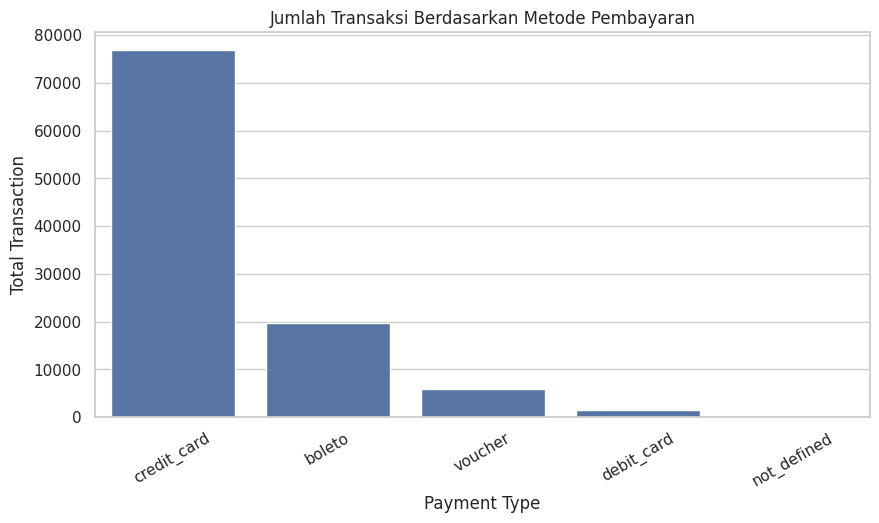

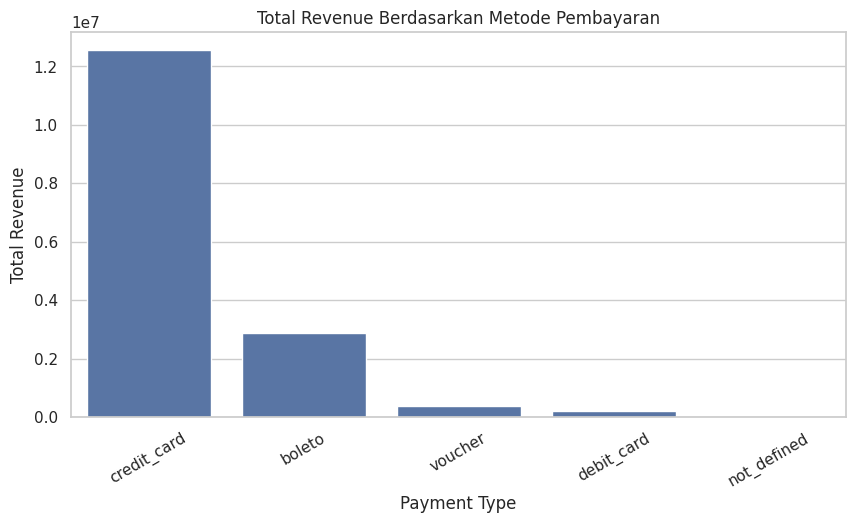

In [62]:
payment_summary = payments_df.groupby('payment_type').agg({
    'order_id':'count',
    'payment_value':'sum'
}).reset_index()

payment_summary.columns = [
    'payment_type',
    'total_transaction',
    'total_revenue'
]

payment_summary = payment_summary.sort_values(
    by='total_revenue',
    ascending=False
)
print(payment_summary)
plt.figure(figsize=(10,5))
sns.barplot(data=payment_summary, x='payment_type', y='total_transaction')
plt.title('Jumlah Transaksi Berdasarkan Metode Pembayaran')
plt.xlabel('Payment Type')
plt.ylabel('Total Transaction')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=payment_summary, x='payment_type', y='total_revenue')
plt.title('Total Revenue Berdasarkan Metode Pembayaran')
plt.xlabel('Payment Type')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.show()

## Pertanyaan 3: Bagaimana distribusi pelanggan ke dalam segmen berdasarkan analisis RFM selama periode September 2016 hingga Agustus 2018?

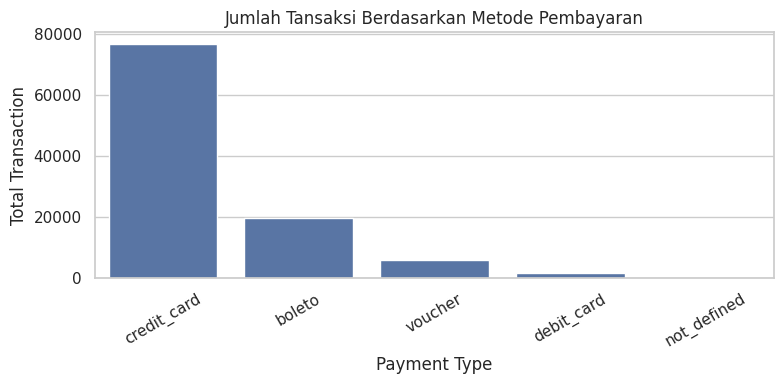

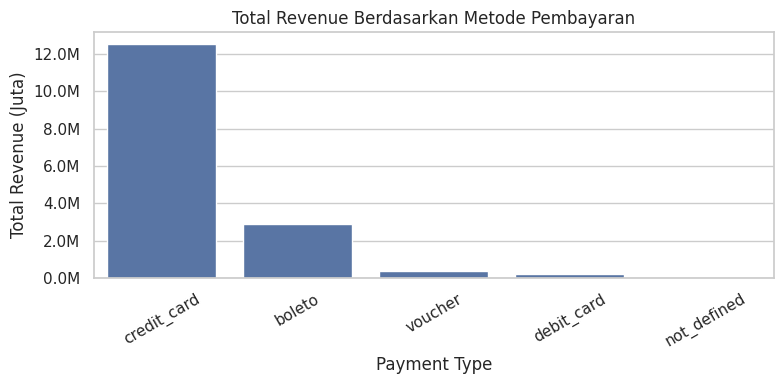

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

payment_summary = payments_df.groupby('payment_type').agg({
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()

payment_summary.columns = [
    'payment_type',
    'total_transaction',
    'total_revenue'
]

payment_summary = payment_summary.sort_values(
    by='total_revenue',
    ascending=False
)

plt.figure(figsize=(8,4))
sns.barplot(data=payment_summary, x='payment_type', y='total_transaction')

plt.title('Jumlah Tansaksi Berdasarkan Metode Pembayaran')
plt.xlabel('Payment Type')
plt.ylabel('Total Transaction')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
ax = sns.barplot(data=payment_summary, x='payment_type', y='total_revenue')

plt.title('Total Revenue Berdasarkan Metode Pembayaran')
plt.xlabel('Payment Type')
plt.ylabel('Total Revenue (Juta)')
plt.xticks(rotation=30)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M')
)

plt.tight_layout()
plt.show()


**Insight:** (Opsional)
Pertanyaan 1:
  - pesanan yang dikirim tepat waktu memiliki rata-rata review score jauh lebih tinggi daripada pesanan yang terlambat.
  - selisih rata-rata review score anta "On Time" dan "Late" cukup signifikan, hal ini menunjukkan bahwa ketepatan waktu merupakan faktor penting dalam pengalaman pelanggan.
  - keterlambatan berdampak negatif terhadap kepuasan pelanggan, hal ini dapat dilihat dari rata-rata skor review.
  - mayoritas pelanggan cenderung memberikan penilaian lebih baik ketika pesanan diterima sesuai estimasi waktu.

Pertanyaan 2:
  - metode yang paling dominan digunakan adalah credit card, baik dari jumlah transaksi maupun total revenue.
  - terdapat gap yang besar antara credit card dengan metode pembayaran lainnya, menunjukkan preferensi kuat pelanggan terhadap metode ini.
  - boleto menempati posisi kedua, namun jumlah transaksi dan total revenue-nya masih jauh di bawah credit card.
  - hal ini menunjukkan bahwa metode pembayaran digital terutama credit card menjadi pilihan utama pelanggan dalam periode tersebut.

Pertanyaan 3:
  - regular customer masih memiliki jumlah yang signifikan, yang berarti masih ada basis pelanggan aktif yang dapat dipertahankan.
  - jumlah "Lost Customer" lebih banyak dibandingkan "Regular Customer", hal ini menunjukkan bahwa sebagian besar pelanggan sudah tidak aktif melakukan transaksi.
  - terdapat tingkat kehilangan pelanggan yang cukup tinggi dalam periode tersebut.
  - diperlukan strategi khusus misalnya promosi untuk menarik kembali pelanggan yang sudah tidak aktif.
  


## Analisis Lanjutan (Opsional)

In [64]:
rfm_df.describe()

,last_order_date,frequency,monetary,recency
count,99419,99419.0,99419.000000,99419.000000
mean,2017-12-31 07:30:59.143715072,1.0,160.973044,241.799324
min,2016-09-04 21:15:19,1.0,0.000000,0.000000
25%,2017-09-12 14:25:31,1.0,62.010000,118.000000
50%,2018-01-18 22:31:18,1.0,105.290000,223.000000
75%,2018-05-04 15:05:38.500000,1.0,176.950000,352.000000
max,2018-08-30 15:11:58,1.0,13664.080000,724.000000
std,NaN,0.0,221.870233,153.631171


## Conclusion & Recommendation

setelah menganalisis dataset dapat diperoleh kesimpulan:

- Pertanyaan 1:
  1. pesanan tepat waktu memiliki review score yang lebih tinggi dibanding pesanan terlambat.
  2. keterlambatan pengiriman berpengaruh pada kepuasan pelanggan.

- Pertanyaan 2:
  1. metode pembayaran yang sering digunakan adalah credit card.
  2. Metode pembayaran dengan transaksi terbanyak dan revenue terbesar dapat dijadikan fokus promosi.

- Pertanyaan 3:
  1. Sebagian besar pelanggan berada pada segmen Regular Customer, yaitu pelanggan dengan frekuensi pembelian sedang dan nilai transaksi standar
  2. Segmen Lost Customer menunjukkan adanya pelanggan yang sudah lama tidak melakukan transaksi kembali

**Rekomendasi Action Item:**
- meningkatkan performa logistik agar keterlambatan berkurang
- mengadakan promo cashback pada metode pembayaran paling populer
- dapat melakukan promosi bisa dengan cara diskon bundling produk

In [65]:
!pip install streamlit

In [66]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(
    page_title="Dashboard Analisis E-Commerce",
    layout="wide"
)

sns.set(style="whitegrid")


@st.cache_data
def load_data():
    BASE_DIR = Path(__file__).resolve().parent

    orders_df = pd.read_csv(BASE_DIR / "orders_dataset.csv")
    reviews_df = pd.read_csv(BASE_DIR / "order_reviews_dataset.csv")
    payments_df = pd.read_csv(BASE_DIR / "order_payments_dataset.csv")

    # convert datetime
    date_cols = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]

    for col in date_cols:
        orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

    # filter tanggal
    orders_df = orders_df[
        (orders_df["order_purchase_timestamp"] >= "2016-09-01") &
        (orders_df["order_purchase_timestamp"] <= "2018-08-31")
    ]

    orders_rfm_df = orders_df.copy()

    orders_df = orders_df.dropna(subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ])

    # delivery status
    orders_df["delivery_status"] = np.where(
        orders_df["order_delivered_customer_date"] <=
        orders_df["order_estimated_delivery_date"],
        "On Time",
        "Late"
    )

    # filter review score valid
    reviews_df = reviews_df[
        reviews_df["review_score"].between(1, 5)
    ]

    # create date column
    orders_df["order_date"] = orders_df["order_purchase_timestamp"].dt.date
    orders_rfm_df["order_date"] = orders_rfm_df["order_purchase_timestamp"].dt.date

    return orders_df, reviews_df, payments_df, orders_rfm_df


orders_df, reviews_df, payments_df, orders_rfm_df = load_data()


st.title("📊 Dashboard Analisis E-Commerce")
st.caption("Berdasarkan Pertanyaan Bisnis Submission Dicoding")

st.sidebar.header("Filter Dashboard")

min_date = orders_df["order_date"].min()
max_date = orders_df["order_date"].max()

date_range = st.sidebar.date_input(
    "Pilih Rentang Tanggal",
    value=(min_date, max_date),
    min_value=min_date,
    max_value=max_date
)

if len(date_range) == 2:
    start_date, end_date = date_range
else:
    start_date, end_date = min_date, max_date

filtered_orders = orders_df[
    (orders_df["order_date"] >= start_date) &
    (orders_df["order_date"] <= end_date)
]

filtered_rfm = orders_rfm_df[
    (orders_rfm_df["order_date"] >= start_date) &
    (orders_rfm_df["order_date"] <= end_date)
]


st.subheader("Ringkasan Data")

total_orders = filtered_orders["order_id"].nunique()

late_orders = filtered_orders[
    filtered_orders["delivery_status"] == "Late"
]["order_id"].nunique()

late_percent = (late_orders / total_orders) * 100 if total_orders > 0 else 0

col1, col2, col3 = st.columns(3)

col1.metric("Total Orders", f"{total_orders:,}")
col2.metric("Late Orders", f"{late_orders:,}")
col3.metric("Late Percentage", f"{late_percent:.2f}%")


st.header("1️⃣ Pengaruh Keterlambatan terhadap Review Score")

review_order_df = pd.merge(
    filtered_orders[["order_id", "delivery_status"]],
    reviews_df[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

avg_review = review_order_df.groupby(
    "delivery_status"
)["review_score"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=avg_review, x="delivery_status", y="review_score", ax=ax)
ax.set_title("Rata-rata Review Score")
st.pyplot(fig)


st.header("2️⃣ Metode Pembayaran Paling Dominan")

payment_summary = payments_df.groupby("payment_type").agg({
    "order_id": "count",
    "payment_value": "sum"
}).reset_index()

payment_summary.columns = [
    "payment_type",
    "total_transaction",
    "total_revenue"
]

payment_summary = payment_summary.sort_values(
    by="total_revenue",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=payment_summary, x="payment_type", y="total_transaction", ax=ax)
plt.xticks(rotation=30)
ax.set_title("Jumlah Transaksi per Payment Type")
st.pyplot(fig)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=payment_summary, x="payment_type", y="total_revenue", ax=ax)
plt.xticks(rotation=30)
ax.set_title("Total Revenue per Payment Type")
st.pyplot(fig)

top_payment = payment_summary.iloc[0]["payment_type"]

st.info(f"Metode pembayaran paling dominan adalah **{top_payment}**.")


st.header("3️⃣ Segmentasi Pelanggan (RFM)")

rfm_df = pd.merge(
    filtered_rfm[["order_id", "customer_id", "order_purchase_timestamp"]],
    payments_df[["order_id", "payment_value"]],
    on="order_id",
    how="inner"
)

rfm_df = rfm_df.groupby("customer_id").agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "payment_value": "sum"
}).reset_index()

rfm_df.columns = [
    "customer_id",
    "last_order",
    "frequency",
    "monetary"
]

recent_date = filtered_rfm["order_purchase_timestamp"].max()

rfm_df["recency"] = (recent_date - rfm_df["last_order"]).dt.days

rfm_df["segment"] = np.where(
    (rfm_df["frequency"] >= 3) & (rfm_df["monetary"] >= 300),
    "Best Customer",
    np.where(
        rfm_df["recency"] > 180,
        "Lost Customer",
        "Regular Customer"
    )
)

segment_count = rfm_df["segment"].value_counts().reset_index()
segment_count.columns = ["segment", "total_customer"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=segment_count, x="segment", y="total_customer", ax=ax)
ax.set_title("Jumlah Pelanggan per Segmen")
st.pyplot(fig)

st.info("Best Customer perlu dipertahankan, Lost Customer perlu diaktivasi kembali.")


st.header("📌 Kesimpulan")

st.markdown("""
- Pesanan tepat waktu memiliki review lebih baik.
- Metode pembayaran tertentu mendominasi transaksi.
- Mayoritas pelanggan adalah Regular Customer.
- Ada segmen Best Customer yang penting untuk bisnis.
""")

st.header("🚀 Rekomendasi")

st.markdown("""
1. Tingkatkan logistik agar tidak terlambat.
2. Optimalkan metode pembayaran dominan.
3. Berikan reward untuk Best Customer.
4. Reaktivasi Lost Customer.
""")


Overwriting dashboard.py


In [67]:
!ls

customers_dataset.csv	    product_category_name_translation.csv
dashboard.py		    products_dataset.csv
geolocation_dataset.csv     README.md
order_items_dataset.csv     requirements.txt
order_payments_dataset.csv  sample_data
order_reviews_dataset.csv   sellers_dataset.csv
orders_dataset.csv


In [68]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 1s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [69]:
!streamlit run dashboard.py & lt --port 8051

your url is: https://every-ghosts-fail.loca.lt



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.185.174:8501

  Stopping...
^C


In [70]:
%%writefile requirements.txt
streamlit
pandas
numpy
matplotlib
seaborn

Overwriting requirements.txt


In [71]:
%%writefile README.md
 Proyek Analisis Data E-Commerce

 Deskripsi Proyek
Proyek ini bertujuan untuk menganalisis **E-Commerce Public Dataset** guna mengetahui pengaruh keterlambatan pengiriman terhadap kepuasan pelanggan, metode pembayaran yang paling dominan, serta segmentasi pelanggan berdasarkan analisis RFM.

 Pertanyaan Bisnis
1. Apakah terdapat perbedaan signifikan pada rata-rata review score antara pesanan yang dikirim tepat waktu dan pesanan yang terlambat selama periode September 2016 hingga Agustus 2018?

2. Metode pembayaran apa yang paling banyak digunakan dan menghasilkan total transaksi terbesar selama periode September 2016 hingga Agustus 2018?
3. Bagaimana distribusi pelanggan ke dalam segmen berdasarkan analisis RFM?

Insight Utama

- Pesanan yang dikirim tepat waktu memiliki rata-rata review score lebih tinggi dibandingkan pesanan yang terlambat.
- Keterlambatan pengiriman berpengaruh terhadap tingkat kepuasan pelanggan.
- Metode pembayaran tertentu mendominasi jumlah transaksi dan kontribusi revenue.
- Sebagian besar pelanggan berada pada segmen **Regular Customer**.
- Terdapat pelanggan bernilai tinggi pada segmen **Best Customer** yang perlu dipertahankan.
- Segmen **Lost Customer** menunjukkan pelanggan yang perlu diaktivasi kembali.


 Struktur Folder

- `Proyek_Analisis_Data.ipynb`
- `dashboard.py`
- `requirements.txt`
- `README.md`
- `orders_dataset.csv`
- `order_reviews_dataset.csv`
- `order_payments_dataset.csv`

 Setup Environment

Install dependencies:

```bash
pip install -r requirements.txt

Overwriting README.md


In [72]:
from pathlib import Path
import os


BASE_DIR = Path("/content/")

print("📁 Folder App :", BASE_DIR)
print("📂 Isi Folder :")

for file in os.listdir(BASE_DIR):
    print("-", file)

📁 Folder App : /content
📂 Isi Folder :
- .config
- dashboard.py
- products_dataset.csv
- product_category_name_translation.csv
- geolocation_dataset.csv
- requirements.txt
- order_items_dataset.csv
- sellers_dataset.csv
- orders_dataset.csv
- order_reviews_dataset.csv
- README.md
- customers_dataset.csv
- order_payments_dataset.csv
- sample_data
